# 06 - LSTM Direction Classifier: Training Pipeline

**Goal:** Train an LSTM to predict whether the next bar closes *higher* (1) or *lower* (0) than the current bar.  
**Data source:** `data/feature_store` (Hive-partitioned Parquet written by the ETL pipeline).  
**Model:** `models.lstm_model.LSTMModel`, stacked LSTM with a single linear head

### Pipeline overview
1. Load raw features from the feature store via `MLDataLoader`
2. Build the next-bar direction target
3. Normalise features (per-feature zero-mean / unit-std, fit on train only)
4. Slide windows -> `(n_samples, seq_len, n_features)` arrays
5. Train / validate / test split (time-ordered)
6. Train the LSTM
7. Evaluate: metrics + confusion matrix
8. Plot training curves
9. Save the model

## 0. Setup

In [1]:
import sys
from pathlib import Path

# Make sure the project root is on the path regardless of where the notebook runs.
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

from financials.etl_pipeline import MLDataLoader
from models.lstm_model import LSTMModel

plt.style.use("seaborn-v0_8-darkgrid")
pd.set_option("display.max_columns", 40)
print("Imports OK")

2026-05-02 16:17:25.975 | DEBUG    | financials.features.registry:_register_builtins:151 - Registered 15 built-in features


Imports OK


## 1. Configuration

Adjust `DATASET_PATH`, `SYMBOLS`, and the date range to match the local feature store.

In [2]:
# ── Data ──────────────────────────────────────────────────────────────────────
DATASET_PATH = PROJECT_ROOT / "data" / "feature_store"

columns_loader = MLDataLoader(DATASET_PATH)
SYMBOLS      = list(columns_loader.available_symbols())
TRAIN_START  = "2020-01-04"
TRAIN_END    = "2024-12-31"
TEST_START   = "2025-01-01"   # held-out test window
TEST_END     = "2026-03-31"

# ── Sequence ──────────────────────────────────────────────────────────────────
SEQUENCE_LENGTH = 390     # look-back window in bars (~3 months of daily data)
STRIDE          = 15      # step between consecutive windows

# ── Model ─────────────────────────────────────────────────────────────────────
MODEL_NAME   = "lstm_direction_v1"
HIDDEN_SIZE  = 128
NUM_LAYERS   = 2
DROPOUT      = 0.2
LR           = 1e-3
BATCH_SIZE   = 256
EPOCHS       = 20
RANDOM_STATE = 42

# ── Feature columns (~30) ─────────────────────────────────────────────────────
# These names match what the ETL pipeline writes to the feature store.
# Series features keep their plain name; composite features are <name>_<sub>.
FEATURE_COLUMNS = [
    # OHLCV (5)
    "open", "high", "low", "close", "volume",
    # Returns (2)
    "returns", "log_returns",
    # Moving averages (4)
    "sma", "ema", "wma", "hma",
    # Momentum (1)
    "rsi",
    # MACD (3)
    "macd_macd", "macd_signal", "macd_histogram",
    # Bollinger Bands (3)
    "bollinger_bands_upper", "bollinger_bands_middle", "bollinger_bands_lower",
    # Volatility / ATR (2)
    "atr", "volatility",
    # Rolling statistics (4)
    "rolling_stats_rolling_mean", "rolling_stats_rolling_std",
    "rolling_stats_rolling_skew", "rolling_stats_rolling_kurtosis",
    # Volume (2)
    "volume_features_volume_sma", "volume_features_volume_ratio", "volume_features_obv",
    # Price structure (3)
    "price_features_high_low_range",
    "price_features_close_open_range",
    "price_features_gap",
]

N_FEATURES = len(FEATURE_COLUMNS)
print(f"Feature columns: {N_FEATURES}")
print(FEATURE_COLUMNS)

Feature columns: 30
['open', 'high', 'low', 'close', 'volume', 'returns', 'log_returns', 'sma', 'ema', 'wma', 'hma', 'rsi', 'macd_macd', 'macd_signal', 'macd_histogram', 'bollinger_bands_upper', 'bollinger_bands_middle', 'bollinger_bands_lower', 'atr', 'volatility', 'rolling_stats_rolling_mean', 'rolling_stats_rolling_std', 'rolling_stats_rolling_skew', 'rolling_stats_rolling_kurtosis', 'volume_features_volume_sma', 'volume_features_volume_ratio', 'volume_features_obv', 'price_features_high_low_range', 'price_features_close_open_range', 'price_features_gap']


## 2. Load, normalise, and build streaming DataLoaders

Scaler is fitted with `partial_fit` one symbol at a time. Training, validation and test windows are then emitted lazily by `StreamingSequenceDataset`, so the full window tensor never has to fit in RAM.

In [3]:
loader = MLDataLoader(DATASET_PATH)

print("Available dates (first/last):",
      loader.available_dates()[:1], "...", loader.available_dates()[-1:])
print("Available symbols:", loader.available_symbols())

Available dates (first/last): ['2021-01-04'] ... ['2026-04-30']
Available symbols: ['AAL', 'AAPL', 'ABNB', 'ALGT', 'ALK', 'AMD', 'AMZN', 'BBY', 'BKNG', 'BKSY', 'CAT', 'CEG', 'CHWY', 'CME', 'CMG', 'CNI', 'COIN', 'COP', 'COST', 'CP', 'CRWD', 'CSX', 'CVS', 'CVX', 'CZR', 'D', 'DAL', 'DE', 'DG', 'DLR', 'DLTR', 'DPZ', 'DRI', 'DUK', 'DVN', 'EBAY', 'ENB', 'EOG', 'EQIX', 'ETSY', 'EXC', 'EXPE', 'F', 'FCX', 'FDX', 'GM', 'GOOGL', 'H', 'HD', 'HLT', 'IAG', 'ICE', 'INTC', 'JBHT', 'JBLU', 'KMI', 'KNX', 'KR', 'LCID', 'LOW', 'LSTR', 'LUV', 'LVS', 'LYFT', 'MA', 'MAR', 'MATX', 'MCD', 'META', 'MGM', 'MPC', 'MSFT', 'NEE', 'NEM', 'NET', 'NFLX', 'NSC', 'NVDA', 'O', 'ODFL', 'OKE', 'OXY', 'PINS', 'PL', 'PLD', 'PSX', 'PYPL', 'QSR', 'RBLX', 'RIVN', 'RSG', 'RYAAY', 'SBUX', 'SCCO', 'SKYW', 'SNAP', 'SNCY', 'SNOW', 'SO', 'SPG', 'SPIR', 'SQ', 'T', 'TCOM', 'TGT', 'TMUS', 'TSLA', 'TXRH', 'U', 'UAL', 'UBER', 'ULCC', 'UNP', 'UPS', 'V', 'VLO', 'VZ', 'W', 'WM', 'WMB', 'WMT', 'WYNN', 'XOM', 'XPO', 'YUM', 'ZIM']


In [4]:
import gc
from torch.utils.data import DataLoader as TorchDataLoader
from financials.etl_pipeline import StreamingSequenceDataset

load_cols = list(dict.fromkeys(["timestamp", "symbol", "close"] + FEATURE_COLUMNS))

# Pass 1: fit the scaler on training data, one symbol at a time.
# Notes for memory-bounded containers:
#   - We pull a float32 feature matrix and drop the DataFrame BEFORE
#     calling partial_fit, so peak per-symbol allocation halves.
#   - gc.collect() each loop helps the allocator return pages.
#   - reset_cache() at the end evicts DuckDB's parquet page cache that
#     accumulated while we swept all 125 symbols.
scaler = StandardScaler()
for i, sym in enumerate(SYMBOLS):
    df_sym = (
        loader.load_pandas(
            symbols=[sym], start=TRAIN_START, end=TRAIN_END, columns=load_cols,
        )
        .dropna(subset=FEATURE_COLUMNS)
    )
    if len(df_sym) > 0:
        feats_arr = df_sym[FEATURE_COLUMNS].to_numpy(dtype="float32")
        del df_sym
        scaler.partial_fit(feats_arr)
        del feats_arr
    else:
        del df_sym
    if (i + 1) % 25 == 0:
        gc.collect()
        print(f"  scaler fit: {i + 1}/{len(SYMBOLS)} symbols")

loader.reset_cache()  # release DuckDB pages from the scaler-fit sweep
gc.collect()
print("Scaler fitted.")


# Target: 1 if next bar's close > current close, else 0.
def direction_target(df):
    """Per-symbol next-bar direction. NaN at the last row (no next bar)
    is dropped by StreamingSequenceDataset before windowing."""
    return (df["close"].shift(-1) > df["close"]).astype("float32")


# Date split: hold out the last ~4 months of training for validation
# (time-ordered, so no look-ahead leakage).
VAL_START = "2024-07-01"

# Shared kwargs for the three datasets.
_ds_kw = dict(
    loader=loader,
    scaler=scaler,
    feature_columns=FEATURE_COLUMNS,
    target_fn=direction_target,
    symbols=SYMBOLS,
    sequence_length=SEQUENCE_LENGTH,
    stride=STRIDE,
)

# Training shuffle buffer: 10_000 windows ≈ 72 MB peak.
# Lower is fine for 1-min data because each symbol contributes tens of
# thousands of windows, so even a small buffer mixes many tickers.
# Bump back up to 50_000 if your container has plenty of RAM.
SHUFFLE_BUFFER = 10_000

train_dataset = StreamingSequenceDataset(
    **_ds_kw, start=TRAIN_START, end=VAL_START,
    shuffle_buffer=SHUFFLE_BUFFER, seed=RANDOM_STATE,
)
val_dataset = StreamingSequenceDataset(
    **_ds_kw, start=VAL_START, end=TRAIN_END, shuffle_buffer=0,
)
test_dataset = StreamingSequenceDataset(
    **_ds_kw, start=TEST_START, end=TEST_END, shuffle_buffer=0,
)

# num_workers=0 keeps everything in the main process: DuckDB connections
# don't survive worker fork on every platform. Bump this if you confirm
# your container handles it.
train_loader = TorchDataLoader(train_dataset, batch_size=BATCH_SIZE, num_workers=0)
val_loader   = TorchDataLoader(val_dataset,   batch_size=BATCH_SIZE, num_workers=0)
test_loader  = TorchDataLoader(test_dataset,  batch_size=BATCH_SIZE, num_workers=0)

print("Streaming DataLoaders ready - windows are generated on-the-fly.")


2026-05-02 16:17:38.451 | DEBUG    | financials.etl_pipeline.load.reader:load_pandas:176 - DuckDB query: SELECT "timestamp", "symbol", "close", "open", "high", "low", "volume", "returns", "log_returns", "sma", "ema", "wma", "hma", "rsi",  ... artitioning=1) WHERE date >= ? AND date <= ? AND symbol IN (?)


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

2026-05-02 16:17:56.994 | INFO     | financials.etl_pipeline.load.reader:load_pandas:184 - Loaded 374732 rows from /app/data/feature_store
2026-05-02 16:18:00.682 | DEBUG    | financials.etl_pipeline.load.reader:load_pandas:176 - DuckDB query: SELECT "timestamp", "symbol", "close", "open", "high", "low", "volume", "returns", "log_returns", "sma", "ema", "wma", "hma", "rsi",  ... artitioning=1) WHERE date >= ? AND date <= ? AND symbol IN (?)


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

2026-05-02 16:18:19.733 | INFO     | financials.etl_pipeline.load.reader:load_pandas:184 - Loaded 374989 rows from /app/data/feature_store
2026-05-02 16:18:23.480 | DEBUG    | financials.etl_pipeline.load.reader:load_pandas:176 - DuckDB query: SELECT "timestamp", "symbol", "close", "open", "high", "low", "volume", "returns", "log_returns", "sma", "ema", "wma", "hma", "rsi",  ... artitioning=1) WHERE date >= ? AND date <= ? AND symbol IN (?)


...

  scaler fit: 125/126 symbols


2026-05-02 17:02:47.580 | DEBUG    | financials.etl_pipeline.load.reader:load_pandas:176 - DuckDB query: SELECT "timestamp", "symbol", "close", "open", "high", "low", "volume", "returns", "log_returns", "sma", "ema", "wma", "hma", "rsi",  ... artitioning=1) WHERE date >= ? AND date <= ? AND symbol IN (?)


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

2026-05-02 17:03:07.498 | INFO     | financials.etl_pipeline.load.reader:load_pandas:184 - Loaded 349879 rows from /app/data/feature_store


Scaler fitted.
Streaming DataLoaders ready - windows are generated on-the-fly.


## 3. Feature exploration

Load one representative symbol for NaN checks and distribution plots.  
The full dataset is consumed as a stream during loading (above).

In [5]:
_sample_sym = SYMBOLS[0]
df_sample = (
    loader.load_pandas(
        symbols=[_sample_sym], start=TRAIN_START, end=TRAIN_END, columns=load_cols
    )
    .dropna(subset=FEATURE_COLUMNS)
    .reset_index(drop=True)
)

print(f"Sample symbol: {_sample_sym}  ({len(df_sample):,} rows)")
print("NaN counts per feature (sample):")
nan_counts = df_sample[FEATURE_COLUMNS].isna().sum()
print(nan_counts[nan_counts > 0].to_string() or "  None - all features present")


2026-05-02 17:03:45.497 | DEBUG    | financials.etl_pipeline.load.reader:load_pandas:176 - DuckDB query: SELECT "timestamp", "symbol", "close", "open", "high", "low", "volume", "returns", "log_returns", "sma", "ema", "wma", "hma", "rsi",  ... artitioning=1) WHERE date >= ? AND date <= ? AND symbol IN (?)


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

2026-05-02 17:04:05.718 | INFO     | financials.etl_pipeline.load.reader:load_pandas:184 - Loaded 374732 rows from /app/data/feature_store


Sample symbol: AAL  (374,732 rows)
NaN counts per feature (sample):
Series([], )


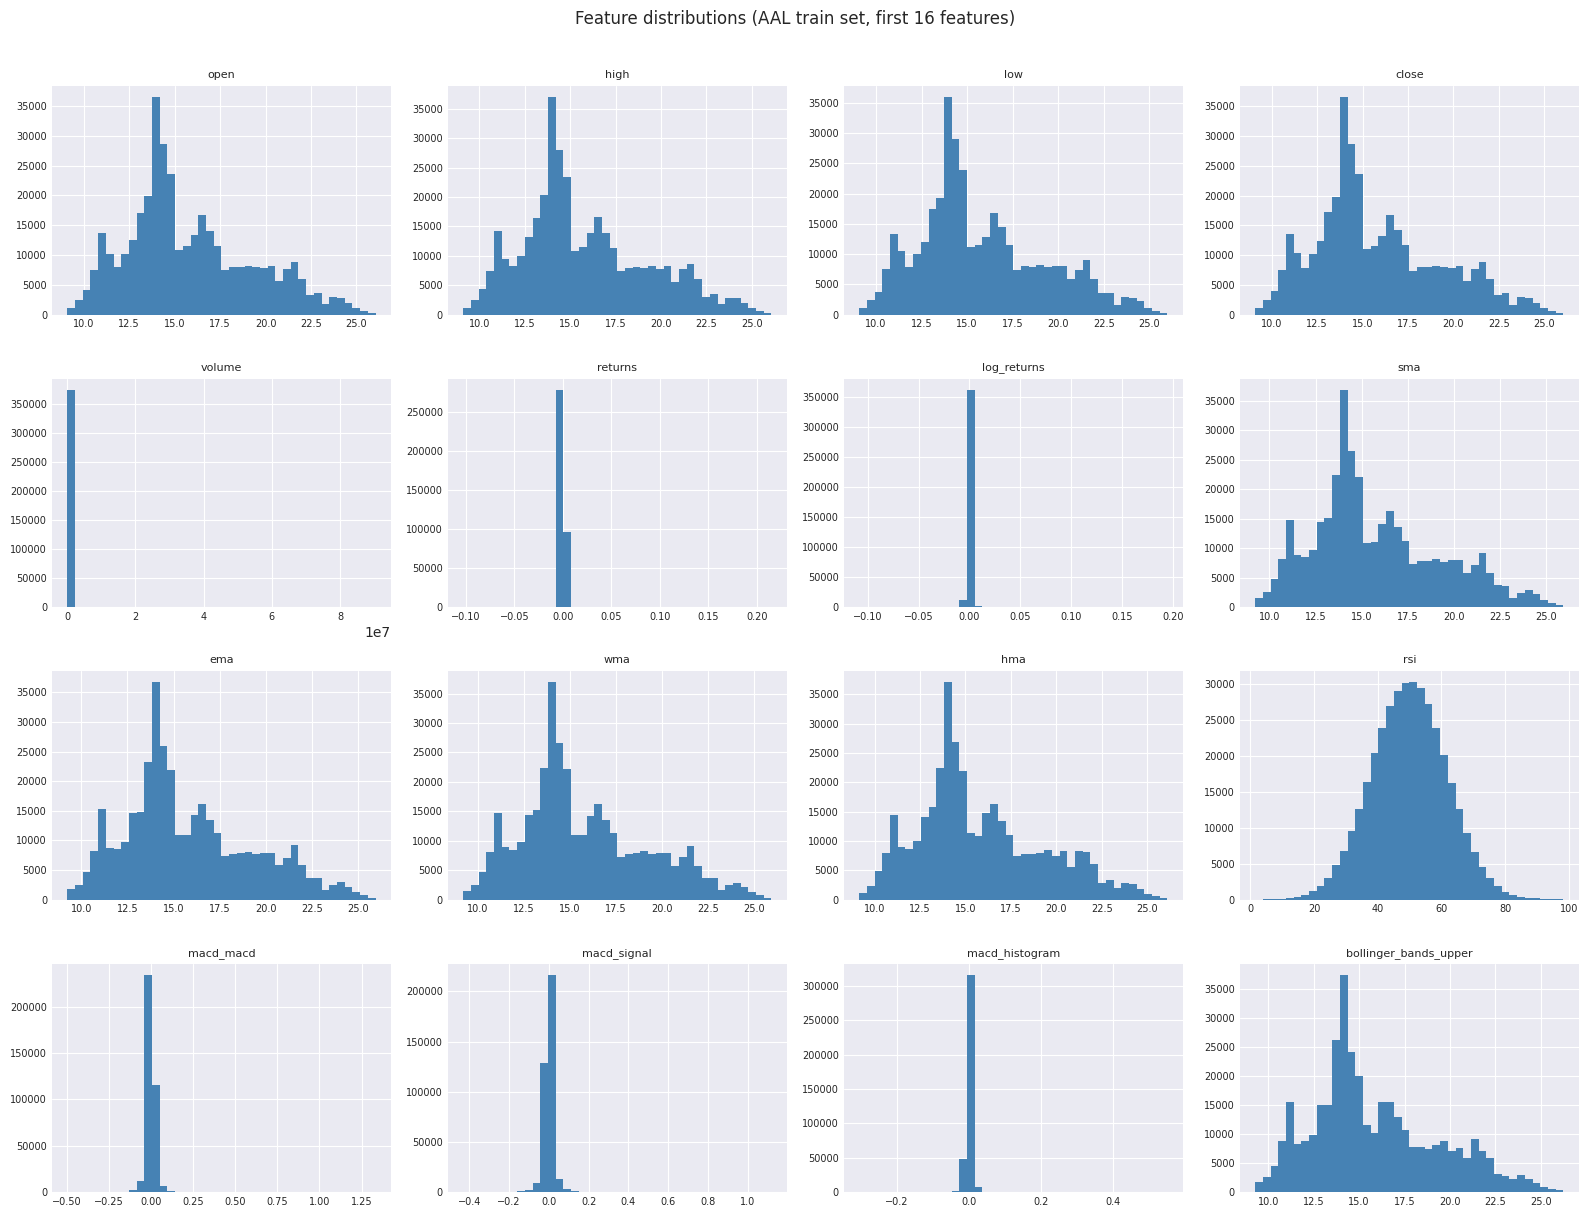

In [6]:
fig, axes = plt.subplots(4, 4, figsize=(16, 12))
for ax, col in zip(axes.ravel(), FEATURE_COLUMNS[:16]):
    df_sample[col].dropna().hist(bins=40, ax=ax, color="steelblue", edgecolor="none")
    ax.set_title(col, fontsize=8)
    ax.tick_params(labelsize=7)
plt.suptitle(f"Feature distributions ({_sample_sym} train set, first 16 features)", y=1.01)
plt.tight_layout()
plt.show()


## 4. Train the LSTM

In [7]:
model = LSTMModel(
    name=MODEL_NAME,
    n_features=N_FEATURES,
    sequence_length=SEQUENCE_LENGTH,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
    learning_rate=LR,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    random_state=RANDOM_STATE,
)

print(f"Device: {model.device}")
print(f"Parameters: {sum(p.numel() for p in model._net.parameters()):,}")

Device: cuda
Parameters: 214,145


In [8]:
# train_from_loader streams batches from the DataLoader each epoch,
# so the full window tensor is never resident in RAM.
model.train_from_loader(train_loader, val_loader=val_loader)

2026-05-02 17:04:15.773 | DEBUG    | financials.etl_pipeline.load.reader:load_pandas:176 - DuckDB query: SELECT "timestamp", "symbol", "open", "high", "low", "close", "volume", "returns", "log_returns", "sma", "ema", "wma", "hma", "rsi",  ... artitioning=1) WHERE date >= ? AND date <= ? AND symbol IN (?)


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

2026-05-02 17:04:28.930 | INFO     | financials.etl_pipeline.load.reader:load_pandas:184 - Loaded 325832 rows from /app/data/feature_store
2026-05-02 17:04:37.410 | DEBUG    | financials.etl_pipeline.load.reader:load_pandas:176 - DuckDB query: SELECT "timestamp", "symbol", "open", "high", "low", "close", "volume", "returns", "log_returns", "sma", "ema", "wma", "hma", "rsi",  ... artitioning=1) WHERE date >= ? AND date <= ? AND symbol IN (?)


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

2026-05-02 17:04:53.471 | INFO     | financials.etl_pipeline.load.reader:load_pandas:184 - Loaded 326079 rows from /app/data/feature_store
2026-05-02 17:05:03.556 | DEBUG    | financials.etl_pipeline.load.reader:load_pandas:176 - DuckDB query: SELECT "timestamp", "symbol", "open", "high", "low", "close", "volume", "returns", "log_returns", "sma", "ema", "wma", "hma", "rsi",  ... artitioning=1) WHERE date >= ? AND date <= ? AND symbol IN (?)


...

2026-05-03 15:12:24.147 | INFO     | financials.etl_pipeline.load.reader:load_pandas:184 - Loaded 48806 rows from /app/data/feature_store
2026-05-03 15:12:25.262 | DEBUG    | financials.etl_pipeline.load.reader:load_pandas:176 - DuckDB query: SELECT "timestamp", "symbol", "open", "high", "low", "close", "volume", "returns", "log_returns", "sma", "ema", "wma", "hma", "rsi",  ... artitioning=1) WHERE date >= ? AND date <= ? AND symbol IN (?)
2026-05-03 15:12:27.404 | INFO     | financials.etl_pipeline.load.reader:load_pandas:184 - Loaded 49300 rows from /app/data/feature_store
2026-05-03 15:12:28.413 | DEBUG    | financials.etl_pipeline.load.reader:load_pandas:176 - DuckDB query: SELECT "timestamp", "symbol", "open", "high", "low", "close", "volume", "returns", "log_returns", "sma", "ema", "wma", "hma", "rsi",  ... artitioning=1) WHERE date >= ? AND date <= ? AND symbol IN (?)
2026-05-03 15:12:30.618 | INFO     | financials.etl_pipeline.load.reader:load_pandas:184 - Loaded 49198 rows fro

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

2026-05-03 15:14:10.685 | INFO     | financials.etl_pipeline.load.reader:load_pandas:184 - Loaded 44379 rows from /app/data/feature_store
2026-05-03 15:14:11.643 | DEBUG    | financials.etl_pipeline.load.reader:load_pandas:176 - DuckDB query: SELECT "timestamp", "symbol", "open", "high", "low", "close", "volume", "returns", "log_returns", "sma", "ema", "wma", "hma", "rsi",  ... artitioning=1) WHERE date >= ? AND date <= ? AND symbol IN (?)
2026-05-03 15:14:13.823 | INFO     | financials.etl_pipeline.load.reader:load_pandas:184 - Loaded 25505 rows from /app/data/feature_store
2026-05-03 15:14:14.658 | DEBUG    | financials.etl_pipeline.load.reader:load_pandas:176 - DuckDB query: SELECT "timestamp", "symbol", "open", "high", "low", "close", "volume", "returns", "log_returns", "sma", "ema", "wma", "hma", "rsi",  ... artitioning=1) WHERE date >= ? AND date <= ? AND symbol IN (?)
2026-05-03 15:14:16.814 | INFO     | financials.etl_pipeline.load.reader:load_pandas:184 - Loaded 49295 rows fro

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

2026-05-03 15:14:50.776 | INFO     | financials.etl_pipeline.load.reader:load_pandas:184 - Loaded 44941 rows from /app/data/feature_store
2026-05-03 15:14:52.146 | DEBUG    | financials.etl_pipeline.load.reader:load_pandas:176 - DuckDB query: SELECT "timestamp", "symbol", "open", "high", "low", "close", "volume", "returns", "log_returns", "sma", "ema", "wma", "hma", "rsi",  ... artitioning=1) WHERE date >= ? AND date <= ? AND symbol IN (?)
2026-05-03 15:14:54.512 | INFO     | financials.etl_pipeline.load.reader:load_pandas:184 - Loaded 48333 rows from /app/data/feature_store
2026-05-03 15:14:55.737 | DEBUG    | financials.etl_pipeline.load.reader:load_pandas:176 - DuckDB query: SELECT "timestamp", "symbol", "open", "high", "low", "close", "volume", "returns", "log_returns", "sma", "ema", "wma", "hma", "rsi",  ... artitioning=1) WHERE date >= ? AND date <= ? AND symbol IN (?)
2026-05-03 15:14:58.173 | INFO     | financials.etl_pipeline.load.reader:load_pandas:184 - Loaded 49202 rows fro

## 5. Training curves

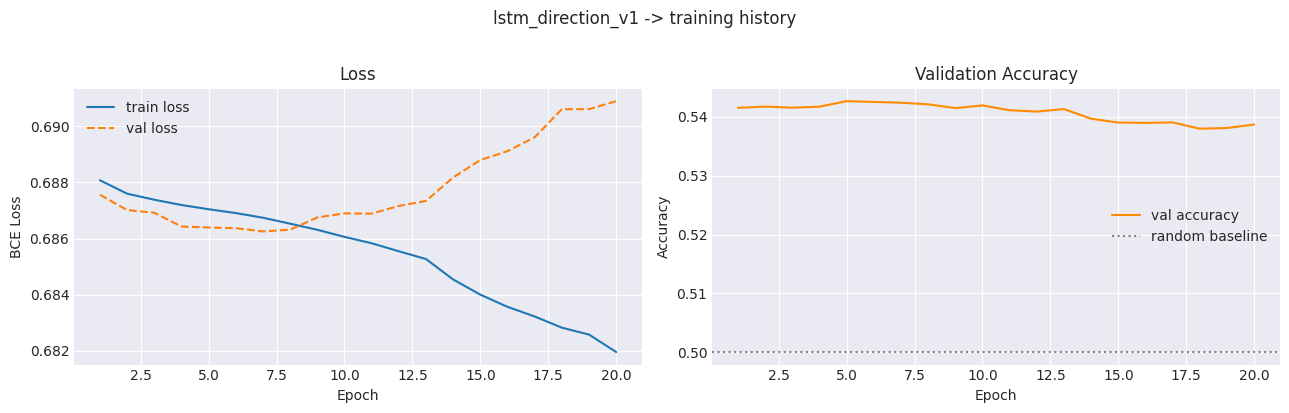

Best val accuracy: 0.5427  (epoch 5)


In [9]:
history = pd.DataFrame(model.train_history)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(history["epoch"], history["train_loss"], label="train loss")
ax1.plot(history["epoch"], history["val_loss"],   label="val loss", linestyle="--")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("BCE Loss")
ax1.set_title("Loss")
ax1.legend()

ax2.plot(history["epoch"], history["val_acc"], color="darkorange", label="val accuracy")
ax2.axhline(0.5, color="grey", linestyle=":", label="random baseline")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.set_title("Validation Accuracy")
ax2.legend()

plt.suptitle(f"{MODEL_NAME} -> training history", y=1.02)
plt.tight_layout()
plt.show()

print(f"Best val accuracy: {history['val_acc'].max():.4f}  "
      f"(epoch {history['val_acc'].idxmax() + 1})")

## 6. Evaluate on the held-out test set

In [10]:
# predict_from_loader streams inference batches and returns the
# corresponding y_true labels - X_test never needs to be a single array.
y_pred, y_proba, y_test = model.predict_from_loader(test_loader)

print("=" * 55)
print(f"Test samples : {len(y_test):,}")
print("=" * 55)
print(classification_report(y_test, y_pred, target_names=["Down (0)", "Up (1)"]))

2026-05-03 15:15:40.178 | DEBUG    | financials.etl_pipeline.load.reader:load_pandas:176 - DuckDB query: SELECT "timestamp", "symbol", "open", "high", "low", "close", "volume", "returns", "log_returns", "sma", "ema", "wma", "hma", "rsi",  ... artitioning=1) WHERE date >= ? AND date <= ? AND symbol IN (?)


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

2026-05-03 15:15:45.582 | INFO     | financials.etl_pipeline.load.reader:load_pandas:184 - Loaded 120531 rows from /app/data/feature_store
2026-05-03 15:15:47.959 | DEBUG    | financials.etl_pipeline.load.reader:load_pandas:176 - DuckDB query: SELECT "timestamp", "symbol", "open", "high", "low", "close", "volume", "returns", "log_returns", "sma", "ema", "wma", "hma", "rsi",  ... artitioning=1) WHERE date >= ? AND date <= ? AND symbol IN (?)


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

2026-05-03 15:15:53.584 | INFO     | financials.etl_pipeline.load.reader:load_pandas:184 - Loaded 120596 rows from /app/data/feature_store
2026-05-03 15:15:56.009 | DEBUG    | financials.etl_pipeline.load.reader:load_pandas:176 - DuckDB query: SELECT "timestamp", "symbol", "open", "high", "low", "close", "volume", "returns", "log_returns", "sma", "ema", "wma", "hma", "rsi",  ... artitioning=1) WHERE date >= ? AND date <= ? AND symbol IN (?)


...

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

2026-05-03 15:31:08.025 | INFO     | financials.etl_pipeline.load.reader:load_pandas:184 - Loaded 118056 rows from /app/data/feature_store
2026-05-03 15:31:10.494 | DEBUG    | financials.etl_pipeline.load.reader:load_pandas:176 - DuckDB query: SELECT "timestamp", "symbol", "open", "high", "low", "close", "volume", "returns", "log_returns", "sma", "ema", "wma", "hma", "rsi",  ... artitioning=1) WHERE date >= ? AND date <= ? AND symbol IN (?)


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

2026-05-03 15:31:15.965 | INFO     | financials.etl_pipeline.load.reader:load_pandas:184 - Loaded 119750 rows from /app/data/feature_store


Test samples : 977,211
              precision    recall  f1-score   support

    Down (0)       0.54      0.77      0.64    519677
      Up (1)       0.50      0.27      0.35    457534

    accuracy                           0.53    977211
   macro avg       0.52      0.52      0.49    977211
weighted avg       0.52      0.53      0.50    977211



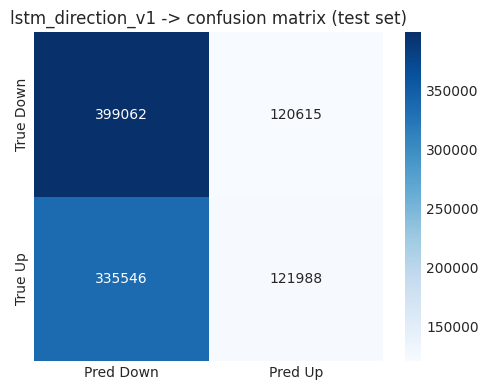

In [11]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues", ax=ax,
    xticklabels=["Pred Down", "Pred Up"],
    yticklabels=["True Down", "True Up"],
)
ax.set_title(f"{MODEL_NAME} -> confusion matrix (test set)")
plt.tight_layout()
plt.show()

In [12]:
# Build the same metrics dict BaseModel.evaluate() would produce, but
# from the streamed predictions so we don't need X_test in RAM.
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
)

metrics = {
    "accuracy":  float(accuracy_score(y_test, y_pred)),
    "precision": float(precision_score(y_test, y_pred, average="weighted", zero_division=0)),
    "recall":    float(recall_score(y_test, y_pred, average="weighted", zero_division=0)),
    "f1":        float(f1_score(y_test, y_pred, average="weighted", zero_division=0)),
    "roc_auc":   float(roc_auc_score(y_test, y_proba)),
}

for key, val in metrics.items():
    print(f"  {key:<20}: {val:.4f}")

  accuracy            : 0.5332
  precision           : 0.5243
  recall              : 0.5332
  f1                  : 0.5015
  roc_auc             : 0.5362


## 7. Probability calibration check

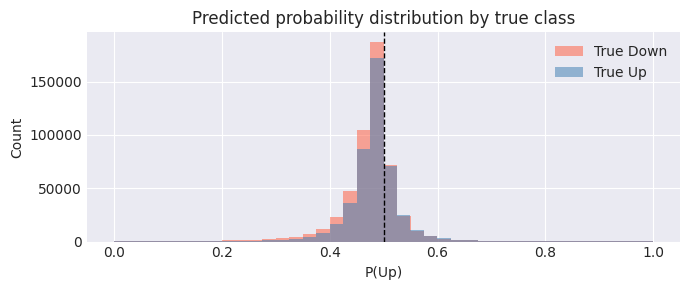

In [13]:
fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(y_proba[y_test == 0], bins=40, alpha=0.55, label="True Down",  color="tomato")
ax.hist(y_proba[y_test == 1], bins=40, alpha=0.55, label="True Up",    color="steelblue")
ax.axvline(0.5, color="black", linestyle="--", linewidth=1)
ax.set_xlabel("P(Up)")
ax.set_ylabel("Count")
ax.set_title("Predicted probability distribution by true class")
ax.legend()
plt.tight_layout()
plt.show()

## 8. Save the model

In [14]:
import joblib

MODELS_DIR = PROJECT_ROOT / "models" / "saved"
model_path  = str(MODELS_DIR / f"{MODEL_NAME}.pt")
scaler_path = str(MODELS_DIR / f"{MODEL_NAME}_scaler.joblib")

model.save(model_path)
joblib.dump(scaler, scaler_path)

print(f"Model  saved: {model_path}")
print(f"Scaler saved: {scaler_path}")

Model  saved: /app/models/saved/lstm_direction_v1.pt
Scaler saved: /app/models/saved/lstm_direction_v1_scaler.joblib


## 9. Round-trip load check

In [15]:
loaded_model = LSTMModel.load(model_path)

# StreamingSequenceDataset's __iter__ produces a deterministic sequence
# in time order when shuffle_buffer=0 (test_loader's setting), so the
# reload predictions line up with y_pred from cell 17.
y_pred_reload, _, _ = loaded_model.predict_from_loader(test_loader)

assert np.array_equal(y_pred, y_pred_reload), "Predictions differ after reload!"
print("Round-trip check passed - predictions are identical after save/load.")

2026-05-03 15:31:20.707 | DEBUG    | financials.etl_pipeline.load.reader:load_pandas:176 - DuckDB query: SELECT "timestamp", "symbol", "open", "high", "low", "close", "volume", "returns", "log_returns", "sma", "ema", "wma", "hma", "rsi",  ... artitioning=1) WHERE date >= ? AND date <= ? AND symbol IN (?)


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

2026-05-03 15:31:33.603 | INFO     | financials.etl_pipeline.load.reader:load_pandas:184 - Loaded 120531 rows from /app/data/feature_store
2026-05-03 15:31:35.770 | DEBUG    | financials.etl_pipeline.load.reader:load_pandas:176 - DuckDB query: SELECT "timestamp", "symbol", "open", "high", "low", "close", "volume", "returns", "log_returns", "sma", "ema", "wma", "hma", "rsi",  ... artitioning=1) WHERE date >= ? AND date <= ? AND symbol IN (?)


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

2026-05-03 15:31:42.619 | INFO     | financials.etl_pipeline.load.reader:load_pandas:184 - Loaded 120596 rows from /app/data/feature_store
2026-05-03 15:31:45.002 | DEBUG    | financials.etl_pipeline.load.reader:load_pandas:176 - DuckDB query: SELECT "timestamp", "symbol", "open", "high", "low", "close", "volume", "returns", "log_returns", "sma", "ema", "wma", "hma", "rsi",  ... artitioning=1) WHERE date >= ? AND date <= ? AND symbol IN (?)


...

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

2026-05-03 15:47:01.727 | INFO     | financials.etl_pipeline.load.reader:load_pandas:184 - Loaded 118056 rows from /app/data/feature_store
2026-05-03 15:47:04.036 | DEBUG    | financials.etl_pipeline.load.reader:load_pandas:176 - DuckDB query: SELECT "timestamp", "symbol", "open", "high", "low", "close", "volume", "returns", "log_returns", "sma", "ema", "wma", "hma", "rsi",  ... artitioning=1) WHERE date >= ? AND date <= ? AND symbol IN (?)


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

2026-05-03 15:47:09.305 | INFO     | financials.etl_pipeline.load.reader:load_pandas:184 - Loaded 119750 rows from /app/data/feature_store


Round-trip check passed - predictions are identical after save/load.


## 10. (Optional) Register with ModelRegistry

Uncomment if you have a running PostgreSQL instance and want to persist metadata.

In [16]:
# from models.registry import ModelRegistry
#
# registry = ModelRegistry()
# training_info = {
#     "symbols"          : SYMBOLS,
#     "features"         : FEATURE_COLUMNS,
#     "sequence_length"  : SEQUENCE_LENGTH,
#     "train_start"      : TRAIN_START,
#     "train_end"        : TRAIN_END,
#     "test_start"       : TEST_START,
#     "test_end"         : TEST_END,
#     "train_samples"    : <count via a streaming pre-pass if needed>,
#     "test_samples"     : <count via a streaming pre-pass if needed>,
#     "scaler_path"      : scaler_path,
# }
# registry.register(model, training_info, metrics, description="LSTM direction classifier v1")